<img src="https://raw.githubusercontent.com/egiuse25/APS/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº5
#### Emilia Giusepponi

## Consigna  
En el repositorio PDStestbench encontrará tres tipos de señales registradas:

Electrocardiograma (ECG). En el archivo ECG_TP4.mat encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.

Pletismografía (PPG). El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.

Audio. Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.
Los detalles de cómo acceder a dichos registros los pueden encontrar en lectura_sigs.py

Se pide:

1) Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

2) Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

Bonus:

💎 Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

## Desarrollo 

En principio, se grafican los espectros de potencia de las señales mediante el método de Welch.

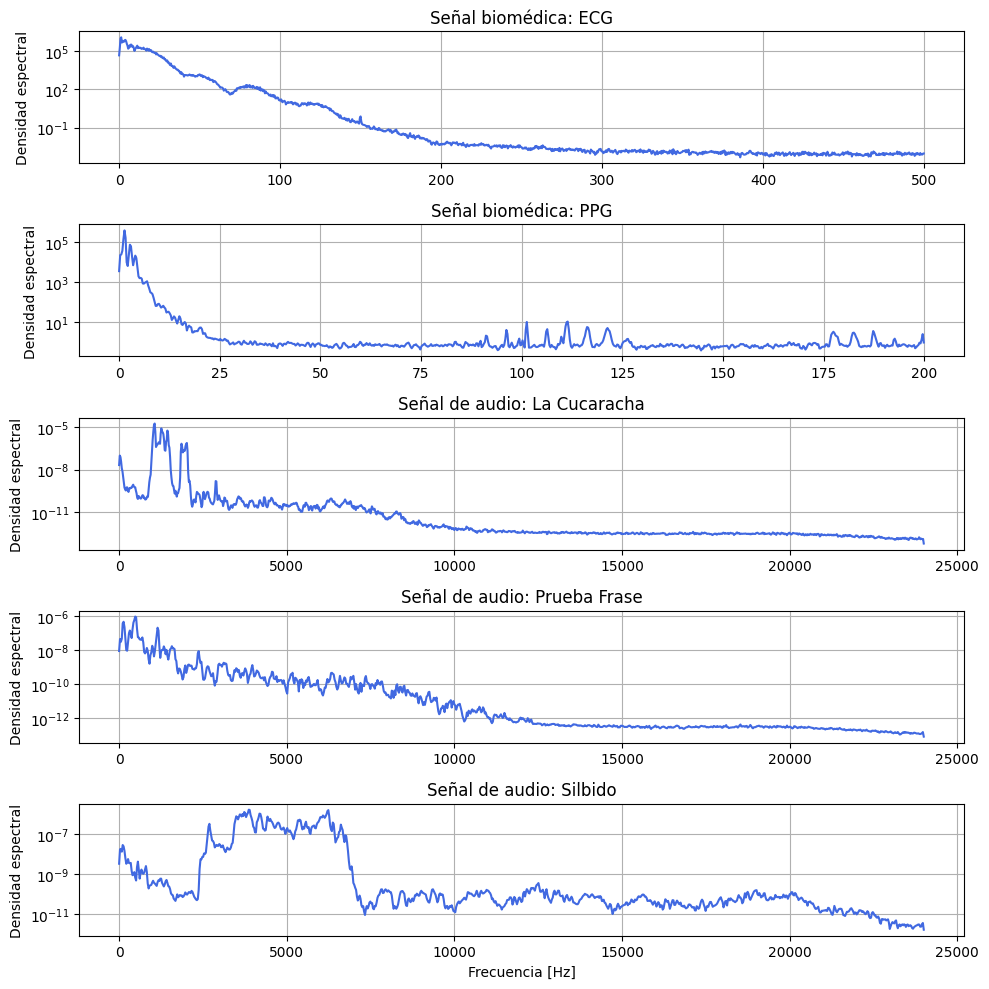

In [75]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io.wavfile import write

'----ECG----'
fs_ecg = 1000 # Hz
ecg_one_lead = np.load('ecg_sin_ruido.npy') 
N_ecg = len(ecg_one_lead)
f_ecg, welch_ecg = sig.welch(ecg_one_lead, fs = fs_ecg, nperseg = N_ecg//13) 

'---- PPG ----'
fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')
N_ppg = len(ppg)
f_ppg, welch_ppg = sig.welch(ppg, fs = fs_ppg, nperseg = N_ppg//30)


'----LA CUCARACHA----'
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav') 
N_cucaracha = len(wav_data)
f_cucaracha, welch_cucaracha = sig.welch(wav_data, fs = fs_audio, nperseg=N_cucaracha//60)

'----SILBIDO----'
fs_silbido, wav_silbido = sio.wavfile.read('silbido.wav') 
N_silbido = len(wav_silbido)
f_silbido, welch_silbido = sig.welch(wav_silbido, fs = fs_silbido, nperseg=N_silbido//80, noverlap=1000)

'----PRUEBA----'
fs_prueba, wav_prueba = sio.wavfile.read('prueba psd.wav') 
N_prueba = len(wav_prueba)
f_prueba, welch_prueba = sig.welch(wav_prueba, fs = fs_prueba, nperseg=N_prueba//80, noverlap=500)

'----GRAFICO----'
fig, axs = plt.subplots(5, 1, figsize=(10, 10))

# --- ECG ---
axs[0].semilogy(f_ecg, welch_ecg, color='royalblue')
axs[0].set_title('Señal biomédica: ECG')
axs[0].set_ylabel('Densidad espectral')
axs[0].grid(True)

# --- PPG ---
axs[1].semilogy(f_ppg, welch_ppg, color='royalblue')
axs[1].set_title('Señal biomédica: PPG')
axs[1].set_ylabel('Densidad espectral')
axs[1].grid(True)

# --- LA CUCARACHA ---
axs[2].semilogy(f_cucaracha, welch_cucaracha, color='royalblue')
axs[2].set_title('Señal de audio: La Cucaracha')
axs[2].set_ylabel('Densidad espectral')
axs[2].grid(True)

# --- PRUEBA PSD ---
axs[3].semilogy(f_prueba, welch_prueba, color='royalblue')
axs[3].set_title('Señal de audio: Prueba Frase')
axs[3].set_ylabel('Densidad espectral')
axs[3].grid(True)

# --- SILBIDO ---
axs[4].semilogy(f_silbido, welch_silbido, color='royalblue')
axs[4].set_title('Señal de audio: Silbido')
axs[4].set_ylabel('Densidad espectral')
axs[4].set_xlabel('Frecuencia [Hz]')
axs[4].grid(True)

plt.tight_layout()
plt.show()

Se utilizó el método de Welch para la estimación espectral de cada una de las señales, ajustando de manera empírica el tamaño de la ventana de análisis (`nperseg`) de cada señal. El objetivo de este ajuste fue encontrar un equilibrio entre la resolución espectral y la varianza del estimador. Un `nperseg` mayor permite una mejor resolución pero disminuye la cantidad de segmentos promediados, lo que introduce ruido y, por lo tanto, una mayor varianza. Por otro lado, un `nperseg` menor mejora la visualización del espectro al disminuir el ruido, pero empeora la resolución espectral. 

A partir de los espectros resultantes, se puede observar cómo las señales biomédicas son pasabajos debido a que conservan casi la totalidad de su energía en las frecuencias más bajas. En contraste, las señales de audio, como 'La Cucaracha' y el silbido, distribuyen su energía en un rango intermedio, característico de señales pasabanda. Esto es debido a que la voz se comporta de esa manera. Sin embargo, se observa un comportamiento similar al de un pasabajos para el audio 'Prueba Frase' dado que pareciera que la mayor parte de su energía se concentra en las bajas frecuencias.

## Ejercicio 2

Se continúa con la estimación del ancho de banda. En primer lugar se calcula a partir de un 95% de la energía total.

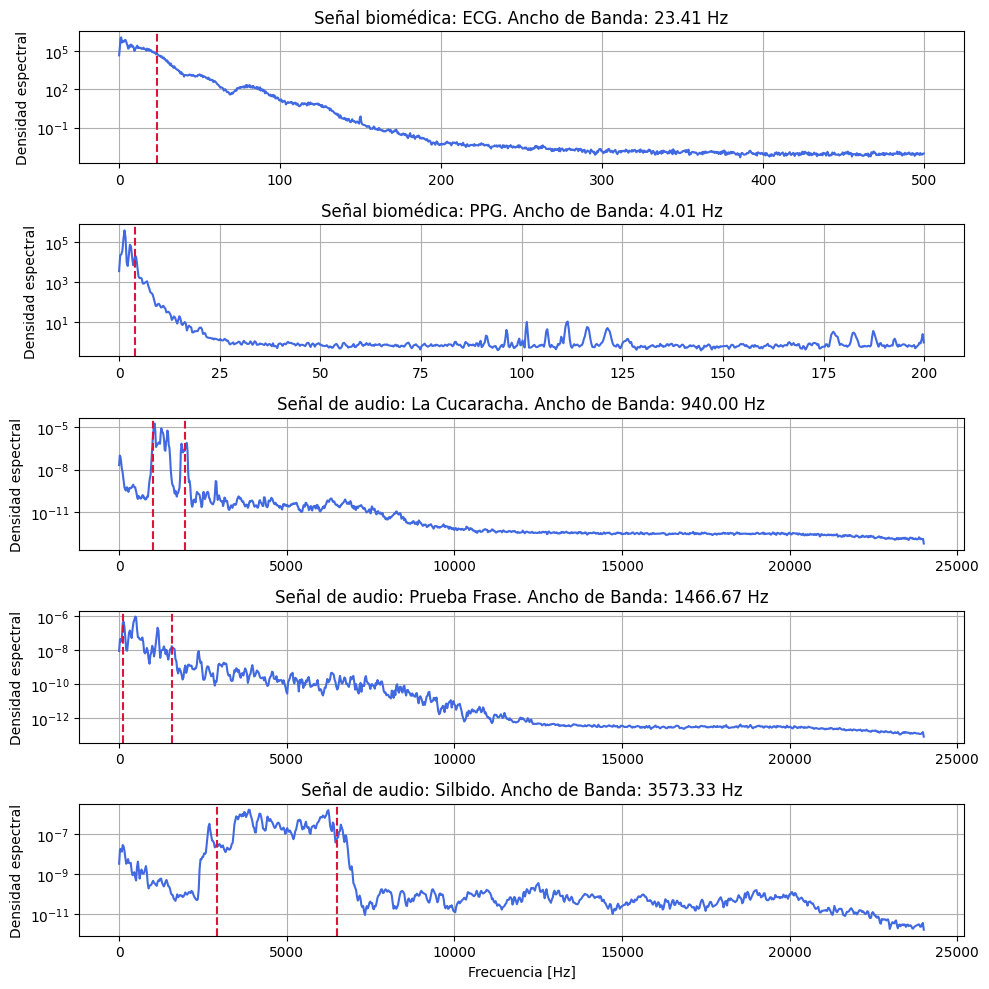

=== Comparación de Anchos de Banda (95% de la energía) ===


,Señal,Tipo de Señal,Frec. Límite Inferior [Hz],Frec. Límite Superior [Hz],Ancho de Banda (BW) [Hz]
0,ECG,Pasabajos,0.00,23.41,23.41
1,PPG,Pasabajos,0.00,4.01,4.01
2,La Cucaracha,Pasabanda,1020.00,1960.00,940.00
3,Silbido,Pasabanda,2933.33,6506.67,3573.33
4,Prueba Frase,Pasabanda,106.67,1573.33,1466.67


In [78]:
'------------ ESTIMACION ANCHO DE BANDA ECG ------------'
f_ecg, welch_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=N_ecg//13) 

potencia_total_ecg = np.sum(welch_ecg)

potencia_acumulada_ecg = 0
indice_corte_ecg = 0

for i in range(len(welch_ecg)):
    potencia_acumulada_ecg += welch_ecg[i]
    porcentaje_actual_ecg = potencia_acumulada_ecg / potencia_total_ecg
    if porcentaje_actual_ecg >= 0.95:
        indice_corte_ecg = i
        break

bw_ecg = f_ecg[indice_corte_ecg]

'------------ ESTIMACION ANCHO DE BANDA PPG ------------'
f_ppg, welch_ppg = sig.welch(ppg, fs = fs_ppg, nperseg = N_ppg//30)

potencia_total_ppg = np.sum(welch_ppg)
potencia_acumulada_ppg = 0
indice_corte_ppg = 0

for i in range(len(welch_ppg)):
    potencia_acumulada_ppg += welch_ppg[i]
    porcentaje_actual_ppg = potencia_acumulada_ppg / potencia_total_ppg
    if porcentaje_actual_ppg >= 0.95:
        indice_corte_ppg = i
        break

bw_ppg = f_ppg[indice_corte_ppg]

'------------ ESTIMACION ANCHO DE BANDA LA CUCARACHA ------------'
f_cucaracha, welch_cucaracha = sig.welch(wav_data, fs = fs_audio, nperseg=N_cucaracha//60)
potencia_total_cucaracha = np.sum(welch_cucaracha)
potencia_acumulada_cucaracha = 0

indice_inferior_cucaracha = 0
indice_superior_cucaracha = 0
encontro_inferior = False 

for i in range(len(welch_cucaracha)):
    potencia_acumulada_cucaracha += welch_cucaracha[i]
    porcentaje_actual_cucaracha = potencia_acumulada_cucaracha / potencia_total_cucaracha
    
    if porcentaje_actual_cucaracha >= 0.025 and not encontro_inferior:
        indice_inferior_cucaracha = i
        encontro_inferior = True 
        
    if porcentaje_actual_cucaracha >= 0.975:
        indice_superior_cucaracha = i
        break

f_min_cucaracha = f_cucaracha[indice_inferior_cucaracha]
f_max_cucaracha = f_cucaracha[indice_superior_cucaracha]

bw_cucaracha= f_max_cucaracha - f_min_cucaracha

'------------ ESTIMACION ANCHO DE BANDA SILBIDO ------------'
potencia_total_silbido = np.sum(welch_silbido)
potencia_acumulada_silbido = 0

indice_inferior_silbido = 0
indice_superior_silbido = 0
encontro_inferior = False 

for i in range(len(welch_silbido)):
    potencia_acumulada_silbido += welch_silbido[i]
    
    porcentaje_actual_silbido = potencia_acumulada_silbido / potencia_total_silbido
    
    if porcentaje_actual_silbido >= 0.025 and not encontro_inferior:
        indice_inferior_silbido = i
        encontro_inferior = True 
        
    if porcentaje_actual_silbido >= 0.975:
        indice_superior_silbido = i
        break

f_min_silbido = f_silbido[indice_inferior_silbido]
f_max_silbido = f_silbido[indice_superior_silbido]
bw_silbido= f_max_silbido - f_min_silbido

'------------ ESTIMACION ANCHO DE BANDA PRUEBA ------------'
potencia_total_prueba = np.sum(welch_prueba)
potencia_acumulada_prueba = 0

indice_inferior_prueba = 0
indice_superior_prueba = 0
encontro_inferior = False

for i in range(len(welch_prueba)):
    potencia_acumulada_prueba += welch_prueba[i]
    porcentaje_actual_prueba = potencia_acumulada_prueba / potencia_total_prueba
    
    if porcentaje_actual_prueba >= 0.025 and not encontro_inferior:
        indice_inferior_prueba = i
        encontro_inferior = True 
        
    if porcentaje_actual_prueba >= 0.975:
        indice_superior_prueba = i
        break

f_min_prueba = f_prueba[indice_inferior_prueba]
f_max_prueba = f_prueba[indice_superior_prueba]

bw_prueba= f_max_prueba - f_min_prueba


'----GRAFICO----'
fig, axs = plt.subplots(5, 1, figsize=(10, 10))

# --- ECG ---
axs[0].semilogy(f_ecg, welch_ecg, color='royalblue')
axs[0].axvline(x=bw_ecg, color='crimson', linestyle='--')
axs[0].set_title(f"Señal biomédica: ECG. Ancho de Banda: {bw_ecg:.2f} Hz")
axs[0].set_ylabel('Densidad espectral')
axs[0].grid(True)

# --- PPG ---
axs[1].semilogy(f_ppg, welch_ppg, color='royalblue')
axs[1].axvline(x=bw_ppg, color='crimson', linestyle='--')
axs[1].set_title(f"Señal biomédica: PPG. Ancho de Banda: {bw_ppg:.2f} Hz")
axs[1].set_ylabel('Densidad espectral')
axs[1].grid(True)

# --- LA CUCARACHA ---
axs[2].semilogy(f_cucaracha, welch_cucaracha, color='royalblue')
axs[2].axvline(x=f_min_cucaracha, color='crimson', linestyle='--')
axs[2].axvline(x=f_max_cucaracha, color='crimson', linestyle='--')
axs[2].set_title(f"Señal de audio: La Cucaracha. Ancho de Banda: {bw_cucaracha:.2f} Hz")
axs[2].set_ylabel('Densidad espectral')
axs[2].grid(True)

# --- PRUEBA PSD ---
axs[3].semilogy(f_prueba, welch_prueba, color='royalblue')
axs[3].axvline(x=f_min_prueba, color='crimson', linestyle='--')
axs[3].axvline(x=f_max_prueba, color='crimson', linestyle='--')
axs[3].set_title(f"Señal de audio: Prueba Frase. Ancho de Banda: {bw_prueba:.2f} Hz")
axs[3].set_ylabel('Densidad espectral')
axs[3].grid(True)

# --- SILBIDO ---
axs[4].semilogy(f_silbido, welch_silbido, color='royalblue')
axs[4].axvline(x=f_min_silbido, color='crimson', linestyle='--')
axs[4].axvline(x=f_max_silbido, color='crimson', linestyle='--')
axs[4].set_title(f"Señal de audio: Silbido. Ancho de Banda: {bw_silbido:.2f} Hz")
axs[4].set_ylabel('Densidad espectral')
axs[4].set_xlabel('Frecuencia [Hz]')
axs[4].grid(True)

plt.tight_layout()
plt.show()

'---- TABLA ----'

datos_tabla = {
    "Señal": ["ECG", "PPG", "La Cucaracha", "Silbido", "Prueba Frase"],
    "Tipo de Señal": ["Pasabajos", "Pasabajos", "Pasabanda", "Pasabanda", "Pasabanda"],
    "Frec. Límite Inferior [Hz]": [0.0, 0.0, f_min_cucaracha, f_min_silbido, f_min_prueba],
    "Frec. Límite Superior [Hz]": [f_ecg[indice_corte_ecg], f_ppg[indice_corte_ppg], f_max_cucaracha, f_max_silbido, f_max_prueba],
    "Ancho de Banda (BW) [Hz]": [bw_ecg, bw_ppg, bw_cucaracha, bw_silbido, bw_prueba]
}

tabla_comparativa = pd.DataFrame(datos_tabla)
print("=== Comparación de Anchos de Banda (95% de la energía) ===")
display(tabla_comparativa.round(2))

Posteriormente se repite el cálculo para el 99% de la energía total. 

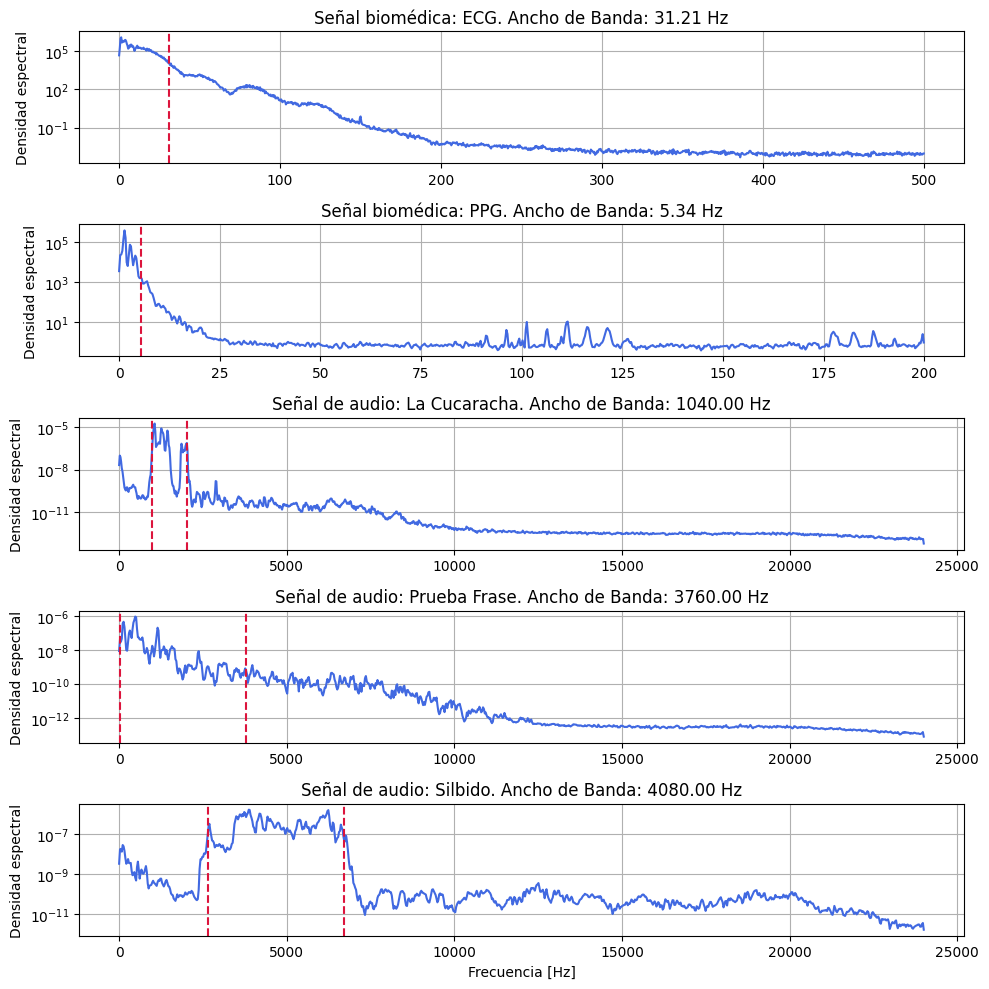

=== Comparación de Anchos de Banda (99% de la energía) ===


,Señal,Tipo de Señal,Frec. Límite Inferior [Hz],Frec. Límite Superior [Hz],Ancho de Banda (BW) [Hz]
0,ECG,Pasabajos,0.00,31.21,31.21
1,PPG,Pasabajos,0.00,5.34,5.34
2,La Cucaracha,Pasabanda,980.00,2020.00,1040.00
3,Silbido,Pasabanda,2640.00,6720.00,4080.00
4,Prueba Frase,Pasabanda,26.67,3786.67,3760.00


In [79]:
'------------ ESTIMACION ANCHO DE BANDA ECG ------------'
f_ecg, welch_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=N_ecg//13) 

potencia_total_ecg = np.sum(welch_ecg)

potencia_acumulada_ecg = 0
indice_corte_ecg = 0

for i in range(len(welch_ecg)):
    potencia_acumulada_ecg += welch_ecg[i]
    porcentaje_actual_ecg = potencia_acumulada_ecg / potencia_total_ecg
    if porcentaje_actual_ecg >= 0.99:
        indice_corte_ecg = i
        break

bw_ecg = f_ecg[indice_corte_ecg]

'------------ ESTIMACION ANCHO DE BANDA PPG ------------'
f_ppg, welch_ppg = sig.welch(ppg, fs = fs_ppg, nperseg = N_ppg//30)

potencia_total_ppg = np.sum(welch_ppg)
potencia_acumulada_ppg = 0
indice_corte_ppg = 0

for i in range(len(welch_ppg)):
    potencia_acumulada_ppg += welch_ppg[i]
    porcentaje_actual_ppg = potencia_acumulada_ppg / potencia_total_ppg
    if porcentaje_actual_ppg >= 0.99:
        indice_corte_ppg = i
        break

bw_ppg = f_ppg[indice_corte_ppg]

'------------ ESTIMACION ANCHO DE BANDA LA CUCARACHA ------------'
f_cucaracha, welch_cucaracha = sig.welch(wav_data, fs = fs_audio, nperseg=N_cucaracha//60)
potencia_total_cucaracha = np.sum(welch_cucaracha)
potencia_acumulada_cucaracha = 0

indice_inferior_cucaracha = 0
indice_superior_cucaracha = 0
encontro_inferior = False 

for i in range(len(welch_cucaracha)):
    potencia_acumulada_cucaracha += welch_cucaracha[i]
    porcentaje_actual_cucaracha = potencia_acumulada_cucaracha / potencia_total_cucaracha
    
    if porcentaje_actual_cucaracha >= 0.005 and not encontro_inferior:
        indice_inferior_cucaracha = i
        encontro_inferior = True 
        
    if porcentaje_actual_cucaracha >= 0.995:
        indice_superior_cucaracha = i
        break

f_min_cucaracha = f_cucaracha[indice_inferior_cucaracha]
f_max_cucaracha = f_cucaracha[indice_superior_cucaracha]

bw_cucaracha= f_max_cucaracha - f_min_cucaracha

'------------ ESTIMACION ANCHO DE BANDA SILBIDO ------------'
potencia_total_silbido = np.sum(welch_silbido)
potencia_acumulada_silbido = 0

indice_inferior_silbido = 0
indice_superior_silbido = 0
encontro_inferior = False 

for i in range(len(welch_silbido)):
    potencia_acumulada_silbido += welch_silbido[i]
    
    porcentaje_actual_silbido = potencia_acumulada_silbido / potencia_total_silbido
    
    if porcentaje_actual_silbido >= 0.005 and not encontro_inferior:
        indice_inferior_silbido = i
        encontro_inferior = True 
        
    if porcentaje_actual_silbido >= 0.995:
        indice_superior_silbido = i
        break

f_min_silbido = f_silbido[indice_inferior_silbido]
f_max_silbido = f_silbido[indice_superior_silbido]
bw_silbido= f_max_silbido - f_min_silbido

'------------ ESTIMACION ANCHO DE BANDA PRUEBA ------------'
potencia_total_prueba = np.sum(welch_prueba)
potencia_acumulada_prueba = 0

indice_inferior_prueba = 0
indice_superior_prueba = 0
encontro_inferior = False 

for i in range(len(welch_prueba)):
    potencia_acumulada_prueba += welch_prueba[i]
    porcentaje_actual_prueba = potencia_acumulada_prueba / potencia_total_prueba
    
    if porcentaje_actual_prueba >= 0.005 and not encontro_inferior:
        indice_inferior_prueba = i
        encontro_inferior = True 
        
    if porcentaje_actual_prueba >= 0.995:
        indice_superior_prueba = i
        break

f_min_prueba = f_prueba[indice_inferior_prueba]
f_max_prueba = f_prueba[indice_superior_prueba]
bw_prueba= f_max_prueba - f_min_prueba

'----GRAFICO----'
fig, axs = plt.subplots(5, 1, figsize=(10, 10))

# --- ECG ---
axs[0].semilogy(f_ecg, welch_ecg, color='royalblue')
axs[0].axvline(x=bw_ecg, color='crimson', linestyle='--')
axs[0].set_title(f"Señal biomédica: ECG. Ancho de Banda: {bw_ecg:.2f} Hz")
axs[0].set_ylabel('Densidad espectral')
axs[0].grid(True)

# --- PPG ---
axs[1].semilogy(f_ppg, welch_ppg, color='royalblue')
axs[1].axvline(x=bw_ppg, color='crimson', linestyle='--')
axs[1].set_title(f"Señal biomédica: PPG. Ancho de Banda: {bw_ppg:.2f} Hz")
axs[1].set_ylabel('Densidad espectral')
axs[1].grid(True)

# --- LA CUCARACHA ---
axs[2].semilogy(f_cucaracha, welch_cucaracha, color='royalblue')
axs[2].axvline(x=f_min_cucaracha, color='crimson', linestyle='--')
axs[2].axvline(x=f_max_cucaracha, color='crimson', linestyle='--')
axs[2].set_title(f"Señal de audio: La Cucaracha. Ancho de Banda: {bw_cucaracha:.2f} Hz")
axs[2].set_ylabel('Densidad espectral')
axs[2].grid(True)

# --- PRUEBA PSD ---
axs[3].semilogy(f_prueba, welch_prueba, color='royalblue')
axs[3].axvline(x=f_min_prueba, color='crimson', linestyle='--')
axs[3].axvline(x=f_max_prueba, color='crimson', linestyle='--')
axs[3].set_title(f"Señal de audio: Prueba Frase. Ancho de Banda: {bw_prueba:.2f} Hz")
axs[3].set_ylabel('Densidad espectral')
axs[3].grid(True)

# --- SILBIDO ---
axs[4].semilogy(f_silbido, welch_silbido, color='royalblue')
axs[4].axvline(x=f_min_silbido, color='crimson', linestyle='--')
axs[4].axvline(x=f_max_silbido, color='crimson', linestyle='--')
axs[4].set_title(f"Señal de audio: Silbido. Ancho de Banda: {bw_silbido:.2f} Hz")
axs[4].set_ylabel('Densidad espectral')
axs[4].set_xlabel('Frecuencia [Hz]')
axs[4].grid(True)

plt.tight_layout()
plt.show()

'---- TABLA ----'

datos_tabla = {
    "Señal": ["ECG", "PPG", "La Cucaracha", "Silbido", "Prueba Frase"],
    "Tipo de Señal": ["Pasabajos", "Pasabajos", "Pasabanda", "Pasabanda", "Pasabanda"],
    "Frec. Límite Inferior [Hz]": [0.0, 0.0, f_min_cucaracha, f_min_silbido, f_min_prueba],
    "Frec. Límite Superior [Hz]": [f_ecg[indice_corte_ecg], f_ppg[indice_corte_ppg], f_max_cucaracha, f_max_silbido, f_max_prueba],
    "Ancho de Banda (BW) [Hz]": [bw_ecg, bw_ppg, bw_cucaracha, bw_silbido, bw_prueba]
}

tabla_comparativa = pd.DataFrame(datos_tabla)
print("=== Comparación de Anchos de Banda (99% de la energía) ===")
display(tabla_comparativa.round(2))

Al observar los resultados obtenidos considerando ambos porcentajes de energía, se hacen evidentes las diferencias entre los dos tipos de señales. Las señales biomédicas poseen anchos de banda pequeños, en comparación a las señales de audio, y concentran su energía desde los 0 Hz. Esto es debido a que el electrocardiograma mide la actividad eléctrica del corazón y la pletismografía mide variaciones de presión o volumen en un órgano o en todo el cuerpo. 

Por otro lado, las señales de audio como La Cucaracha y el silbido poseen anchos de banda considerablemente mayores para poder ser percibidas y transmitidas concentrando su energía a partir de 980 Hz y 2640 Hz respectivamente al 99% de la energía. Al no poseer energía considerable en bajas frecuencias, evidencian un comportamiento típico de señales pasabanda. Por su parte, la señal 'Prueba Frase' confirma su naturaleza de pasabanda. Aunque visualmente parece concentrar gran parte de su energía en frecuencias muy bajas, el cálculo numérico demuestra que su límite inferior es estrictamente mayor a 0 Hz siendo de 26.67 Hz al 99%.

Al aumentar la exigencia de la medición del 95% al 99% de la energía total, se observa un ensanchamiento en los anchos de banda de todas las señales. Sin embargo, elevar el nivel no significa que sea una mejor estimación debido a que al ensanchar el ancho de banda se puede estar incluyendo accidentalmente más ruido en la señal.

### Bonus

La nueva señal analizada proviene del ruido de un ventilador. 

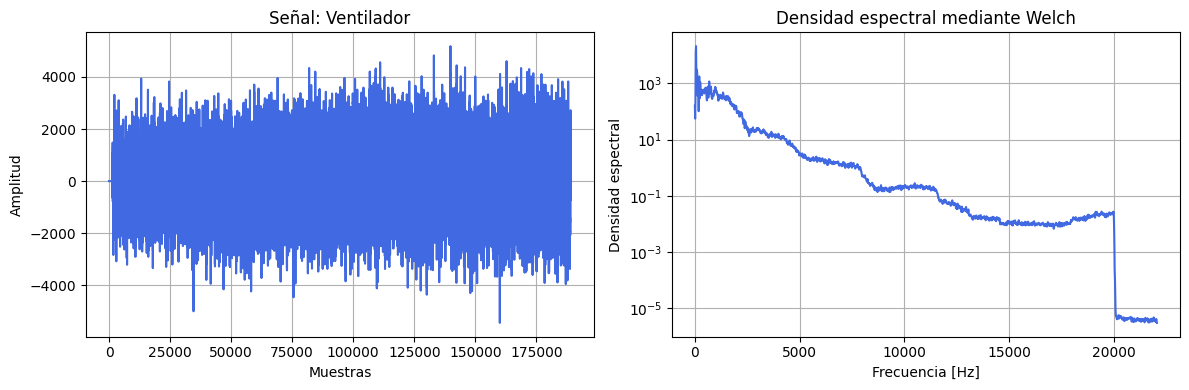

In [119]:
from moviepy import AudioFileClip
import scipy.io as sio
from scipy import signal as sig

clip = AudioFileClip("ventilador.mp4")
clip.write_audiofile("ventilador.wav", logger=None)

fs_ventilador, wav_ventilador = sio.wavfile.read('ventilador.wav') 
N_ventilador = len(wav_ventilador)

if len(wav_ventilador.shape) > 1:
    wav_ventilador = wav_ventilador[:, 0]

f_ventilador, welch_ventilador = sig.welch(wav_ventilador, fs=fs_ventilador, nperseg=N_ventilador//60)

N_ventilador = len(wav_ventilador)


'----GRAFICO----'
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(wav_ventilador, color='royalblue')
axs[0].set_title('Señal: Ventilador')
axs[0].set_xlabel('Muestras')
axs[0].set_ylabel('Amplitud')
axs[0].grid(True)

axs[1].semilogy(f_ventilador, welch_ventilador, color='royalblue')
axs[1].set_title('Densidad espectral mediante Welch')
axs[1].set_ylabel('Densidad espectral')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Al igual que para los anteriores ejercicios se elige empíricamente la cantidad de promedios que utilizará el método de Welch. Se observa que es una señal muy ruidosa por lo que se estableció una ventana de análisis para el método de Welch pequeña, reduciendo la resolución espectral pero logrando un mejor aspecto visual reduciendo la varianza del estimador.

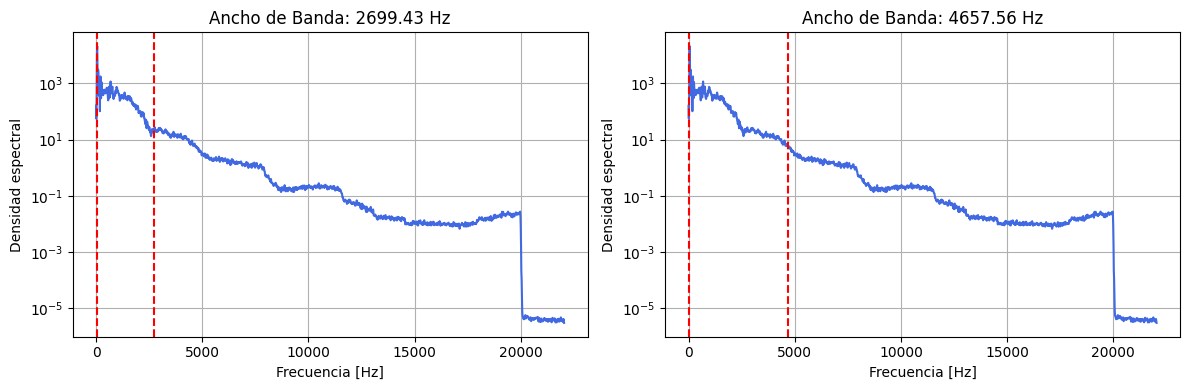

Frecuencia en un porcentaje del 2.5% de energía:  41.96
Frecuencia en un porcentaje del 0.5% de energía:  41.96


In [122]:
'---- ESTIMACION 95% ----'
potencia_total_ventilador_95 = np.sum(welch_ventilador)
potencia_acumulada_ventilador_95 = 0

indice_inferior_ventilador_95 = 0
indice_superior_ventilador_95 = 0
encontro_inferior = False

for i in range(len(welch_ventilador)):
    potencia_acumulada_ventilador_95 += welch_ventilador[i]
    porcentaje_actual_ventilador_95 = potencia_acumulada_ventilador_95 / potencia_total_ventilador_95
    
    if porcentaje_actual_ventilador_95 >= 0.025 and not encontro_inferior:
        indice_inferior_ventilador_95 = i
        encontro_inferior = True 
        
    if porcentaje_actual_ventilador_95 >= 0.975:
        indice_superior_ventilador_95 = i
        break

f_min_ventilador_95 = f_ventilador[indice_inferior_ventilador_95]
f_max_ventilador_95 = f_ventilador[indice_superior_ventilador_95]

bw_ventilador_95 = f_max_ventilador_95 - f_min_ventilador_95

'---- ESTIMACION 99% ----'
potencia_total_ventilador_99 = np.sum(welch_ventilador)
potencia_acumulada_ventilador_99 = 0

indice_inferior_ventilador_99 = 0
indice_superior_ventilador_99 = 0
encontro_inferior = False 

for i in range(len(welch_ventilador)):
    potencia_acumulada_ventilador_99 += welch_ventilador[i]
    porcentaje_actual_ventilador_99 = potencia_acumulada_ventilador_99 / potencia_total_ventilador_99
    
    if porcentaje_actual_ventilador_99 >= 0.005 and not encontro_inferior:
        indice_inferior_ventilador_99 = i
        encontro_inferior = True 
        
    if porcentaje_actual_ventilador_99 >= 0.995:
        indice_superior_ventilador_99 = i
        break

f_min_ventilador_99 = f_ventilador[indice_inferior_ventilador_99]
f_max_ventilador_99 = f_ventilador[indice_superior_ventilador_99]

bw_ventilador_99 = f_max_ventilador_99 - f_min_ventilador_99

'----GRAFICO----'
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].semilogy(f_ventilador, welch_ventilador, color='royalblue')
axs[0].axvline(x=f_min_ventilador_95, color='red', linestyle='--')
axs[0].axvline(x=f_max_ventilador_95, color='red', linestyle='--')
axs[0].set_title(f"Ancho de Banda: {bw_ventilador_95:.2f} Hz")
axs[0].set_ylabel('Densidad espectral')
axs[0].set_xlabel('Frecuencia [Hz]')
axs[0].grid(True)

axs[1].semilogy(f_ventilador, welch_ventilador, color='royalblue')
axs[1].axvline(x=f_min_ventilador_99, color='red', linestyle='--')
axs[1].axvline(x=f_max_ventilador_99, color='red', linestyle='--')
axs[1].set_title(f"Ancho de Banda: {bw_ventilador_99:.2f} Hz")
axs[1].set_ylabel('Densidad espectral')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

print('Frecuencia en un porcentaje del 2.5% de energía: ',f_min_ventilador_95.round(2))
print('Frecuencia en un porcentaje del 0.5% de energía: ',f_min_ventilador_99.round(2))

Se verifica numéricamente que los límites inferiores del ancho de banda de ambas frecuencias en los porcentajes de energía elegidos son iguales. Esto ocurre debido a que el `nperseg` es pequeño y eso empeoró la resolución espectral, provocando que los umbrales de energía de ambos porcentajes caigan dentro del mismo intervalo. Sin embargo, se puede decir que es una señal pasabanda debido a que el límite inferior de su ancho de banda no presenta energía significativa en 0 Hz pero sí la tiene a partir de 41.96 Hz.

### Conclusión

En este trabajo práctico se implementó el método de Welch para la estimación de la densidad espectral de potencia de señales biomédicas y acústicas. Se demostró empíricamente la importancia de la elección del tamaño de ventana de análisis para lograr un equilibrio entre el valor de la resolución espectral y el de la varianza del estimador.

El análisis de ancho de banda permitió diferenciar señales pasabajos de las señales pasabanda. Las señales biomédicas demostraron tener un comportamiento de pasabajos debido a que a frecuencias muy cercanas a cero ya concentran energía significativa. Por el contrario, las señales de audio no presentan energía significativa a bajas frecuencias, siendo un comportamiento típico de señales pasabanda. 

Por último, se evidenció la importancia del porcentaje de energía utilizado para definir el ancho de banda de la señal, debido a que al aumentarlo también aumenta el ancho de banda, pero esto no necesariamente aporta información útil sino que incrementa el riesgo de incluir ruido.